Initial row count: 5542

Original columns:
['cif_id', 'agl_bulk_modulus_isothermal_300K', 'ael_youngs_modulus_vrh']

Renamed columns:
['CIFID', 'AGL_bulk', 'AEL_YOUNGS']

First 10 rows:
                      CIFID  AGL_bulk  AEL_YOUNGS
0      Ac1H2_ICSD_56392.cif   50.0551     78.3652
1  Ag1Al1O2_ICSD_160643.cif  116.4680     92.1706
2  Ag1Al1O2_ICSD_300020.cif  142.0890    132.6010
3   Ag1Al1S2_ICSD_25356.cif   70.7537     84.8939
4  Ag1Al1Se2_ICSD_28745.cif   46.9109     47.3356
5  Ag1Al1Te2_ICSD_28746.cif   36.0103     41.0695
6   Ag1As1Ba1_ICSD_8278.cif   38.1864     69.8235
7  Ag1As1Ca1_ICSD_10017.cif   50.0585     89.4192
8  Ag1As1S1_ICSD_604740.cif   44.9812     33.5341
9  Ag1As1Sr1_ICSD_49742.cif   43.5453     75.2405

Missing values before cleaning:
CIFID         12
AGL_bulk      12
AEL_YOUNGS     0
dtype: int64

Rows dropped due to NaN: 12
Rows dropped due to unphysical values (AGL_bulk < 0 or AEL_YOUNGS < 0): 0
Final cleaned dataset row count: 5530

Descriptive Statistics:
 

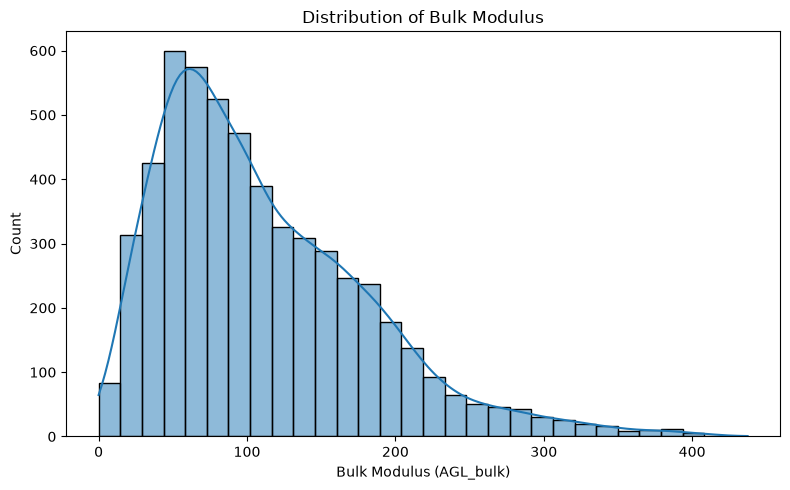

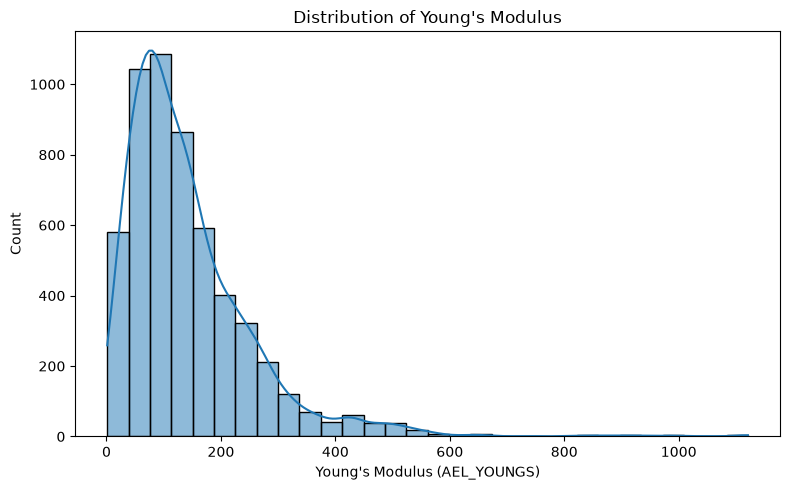

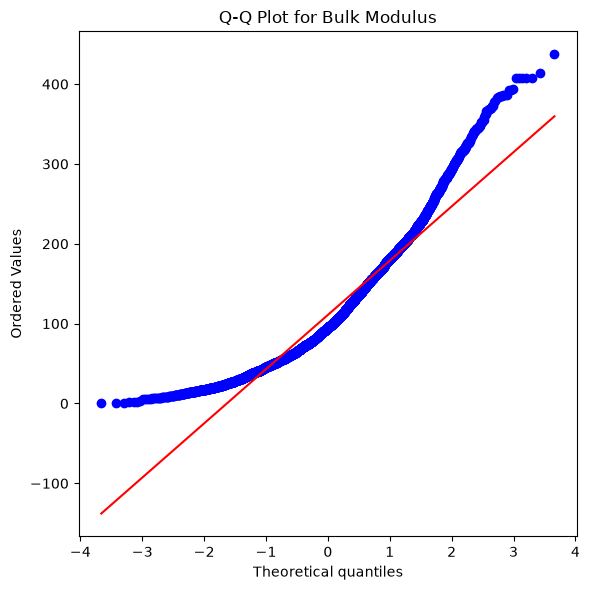

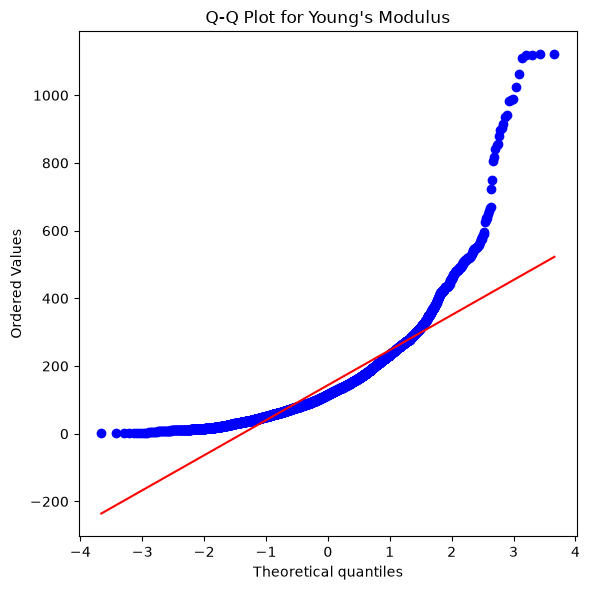


Correlation between Bulk Modulus and Young's Modulus:
0.438166205768923


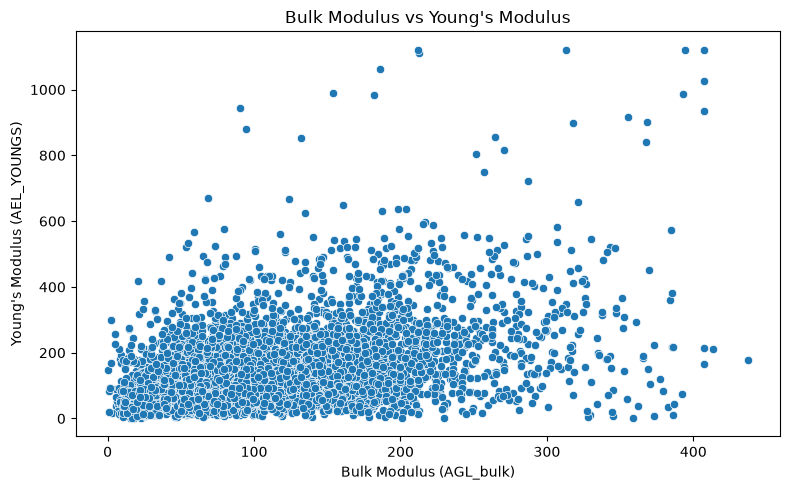


✅ Cleaned dataset successfully saved as:
cleaned_material_properties_dataset.csv


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# ============================================================
# 1. LOAD DATASET
# ============================================================

file_path = 'D:/project/Test_AIMATSC.csv'

df = pd.read_csv(file_path)

print("Initial row count:", len(df))
print("\nOriginal columns:")
print(df.columns.tolist())


# ============================================================
# 2. RENAME COLUMNS
# ============================================================

df = df.rename(columns={
    'cif_id': 'CIFID',
    'agl_bulk_modulus_isothermal_300K': 'AGL_bulk',
    'ael_youngs_modulus_vrh': 'AEL_YOUNGS'
})

print("\nRenamed columns:")
print(df.columns.tolist())


# ============================================================
# 3. DISPLAY FIRST 10 ROWS
# ============================================================

print("\nFirst 10 rows:")
print(df.head(10))


# ============================================================
# 4. CHECK MISSING VALUES
# ============================================================

print("\nMissing values before cleaning:")
print(df[['CIFID', 'AGL_bulk', 'AEL_YOUNGS']].isnull().sum())


# ============================================================
# 5. REMOVE ROWS WITH NaN VALUES
# ============================================================

count_before_dropna = len(df)

df = df.dropna(
    subset=['CIFID', 'AGL_bulk', 'AEL_YOUNGS']
)

rows_dropped_nan = count_before_dropna - len(df)

print("\nRows dropped due to NaN:", rows_dropped_nan)


# ============================================================
# 6. REMOVE UNPHYSICAL VALUES
# ============================================================

valid_mask = (
    (df['AGL_bulk'] >= 0) &
    (df['AEL_YOUNGS'] >= 0)
)

dropped_unphysical = (~valid_mask).sum()

df_clean = df[valid_mask].copy()

print(
    "Rows dropped due to unphysical values "
    "(AGL_bulk < 0 or AEL_YOUNGS < 0):",
    dropped_unphysical
)

print("Final cleaned dataset row count:", len(df_clean))


# ============================================================
# 7. BASIC STATISTICS
# ============================================================

print("\nDescriptive Statistics:")
print(df_clean[['AGL_bulk', 'AEL_YOUNGS']].describe())


# ============================================================
# 8. HISTOGRAM - BULK MODULUS
# ============================================================

plt.figure(figsize=(8, 5))

sns.histplot(
    df_clean['AGL_bulk'],
    kde=True,
    bins=30
)

plt.title('Distribution of Bulk Modulus')
plt.xlabel('Bulk Modulus (AGL_bulk)')
plt.ylabel('Count')

plt.tight_layout()
plt.show()


# ============================================================
# 9. HISTOGRAM - YOUNG'S MODULUS
# ============================================================

plt.figure(figsize=(8, 5))

sns.histplot(
    df_clean['AEL_YOUNGS'],
    kde=True,
    bins=30
)

plt.title("Distribution of Young's Modulus")
plt.xlabel("Young's Modulus (AEL_YOUNGS)")
plt.ylabel("Count")

plt.tight_layout()
plt.show()


# ============================================================
# 10. Q-Q PLOT - BULK MODULUS
# ============================================================

plt.figure(figsize=(6, 6))

stats.probplot(
    df_clean['AGL_bulk'],
    dist='norm',
    plot=plt
)

plt.title('Q-Q Plot for Bulk Modulus')

plt.tight_layout()
plt.show()


# ============================================================
# 11. Q-Q PLOT - YOUNG'S MODULUS
# ============================================================

plt.figure(figsize=(6, 6))

stats.probplot(
    df_clean['AEL_YOUNGS'],
    dist='norm',
    plot=plt
)

plt.title("Q-Q Plot for Young's Modulus")

plt.tight_layout()
plt.show()


# ============================================================
# 12. CORRELATION ANALYSIS
# ============================================================

correlation = df_clean['AGL_bulk'].corr(
    df_clean['AEL_YOUNGS']
)

print("\nCorrelation between Bulk Modulus and Young's Modulus:")
print(correlation)


# ============================================================
# 13. SCATTER PLOT
# ============================================================

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df_clean,
    x='AGL_bulk',
    y='AEL_YOUNGS'
)

plt.title("Bulk Modulus vs Young's Modulus")
plt.xlabel("Bulk Modulus (AGL_bulk)")
plt.ylabel("Young's Modulus (AEL_YOUNGS)")

plt.tight_layout()
plt.show()


# ============================================================
# 14. SAVE CLEANED DATASET
# ============================================================

output_file = 'cleaned_material_properties_dataset.csv'

df_clean.to_csv(
    output_file,
    index=False
)

print("\n✅ Cleaned dataset successfully saved as:")
print(output_file)